In [2]:
# ─────────────────────────────────────────────
# KAGGLE SETUP
# ─────────────────────────────────────────────
import os

BASE      = '/kaggle/working'
MODELS    = '/kaggle/working/models'
DATA_ROOT = '/kaggle/input/datasets/jashrashne/honeycloud'

DATA = {
    'dionaea'   : f'{DATA_ROOT}/dionaeaClean2.csv',
    'aws'       : f'{DATA_ROOT}/AWS_Honeypot_marx-geo.csv',
    'h_summary' : f'{DATA_ROOT}/Hornet40-Dataset-Summary-Table.csv',
    'h_hourly'  : f'{DATA_ROOT}/hornet40-traffic-per-honeypot-hourly-comparative.csv',
    'cic_dir'   : f'{DATA_ROOT}/cic_csv',
}

os.makedirs(MODELS, exist_ok=True)

print("Checking files...")
all_good = True
for name, path in DATA.items():
    exists = os.path.exists(path)
    size   = f"{os.path.getsize(path)/1024/1024:.1f} MB" if exists and os.path.isfile(path) else ""
    status = "✅" if exists else "❌"
    print(f"  {status}  {name:<12} {path} {size}")
    if not exists:
        all_good = False

cic_files = os.listdir(DATA['cic_dir'])
print(f"\n  ✅  CIC files: {len(cic_files)} files found")

if all_good:
    print("\n✅ All paths verified. Ready to train.")
else:
    print("\n❌ Some paths missing.")

Checking files...
  ✅  dionaea      /kaggle/input/datasets/jashrashne/honeycloud/dionaeaClean2.csv 1.9 MB
  ✅  aws          /kaggle/input/datasets/jashrashne/honeycloud/AWS_Honeypot_marx-geo.csv 46.6 MB
  ✅  h_summary    /kaggle/input/datasets/jashrashne/honeycloud/Hornet40-Dataset-Summary-Table.csv 0.0 MB
  ✅  h_hourly     /kaggle/input/datasets/jashrashne/honeycloud/hornet40-traffic-per-honeypot-hourly-comparative.csv 0.1 MB
  ✅  cic_dir      /kaggle/input/datasets/jashrashne/honeycloud/cic_csv 

  ✅  CIC files: 35 files found

✅ All paths verified. Ready to train.


In [3]:
# ─────────────────────────────────────────────
# CELL 2 — Load Dionaea + Hornet40 datasets
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dionaea   = pd.read_csv(DATA['dionaea'],   on_bad_lines='skip', index_col=False)
aws       = pd.read_csv(DATA['aws'],       on_bad_lines='skip', index_col=False)
h_summary = pd.read_csv(DATA['h_summary'], on_bad_lines='skip', index_col=False)
h_hourly  = pd.read_csv(DATA['h_hourly'],  on_bad_lines='skip', index_col=False)

# clean column names
for df in [dionaea, aws, h_summary, h_hourly]:
    df.columns = df.columns.str.strip()

# clean dionaea string values
for col in dionaea.select_dtypes(include='object').columns:
    dionaea[col] = dionaea[col].str.strip()

dionaea['dst_port'] = pd.to_numeric(dionaea['dst_port'], errors='coerce')
dionaea['src_port'] = pd.to_numeric(dionaea['src_port'], errors='coerce')

print("=== DATASET OVERVIEW ===")
print(f"Dionaea   : {len(dionaea):,} rows")
print(f"AWS Geo   : {len(aws):,} rows")
print(f"H Summary : {len(h_summary):,} rows")
print(f"H Hourly  : {len(h_hourly):,} rows")

print("\nTop Dionaea protocols:")
print(dionaea['protocol'].value_counts().head(8))

print("\nTop Dionaea ports:")
print(dionaea['dst_port'].value_counts().head(8))

# clean Hornet40 numeric columns
for col in ['Total Flows', 'Total Unique Src IPs', 'Total Bytes']:
    h_summary[col] = pd.to_numeric(
        h_summary[col].astype(str).str.replace(',',''), errors='coerce')

print("\nHornet40 flows by city:")
print(h_summary[['City','Total Flows','Total Unique Src IPs']].to_string(index=False))

print("\n✅ Datasets loaded.")

=== DATASET OVERVIEW ===
Dionaea   : 27,529 rows
AWS Geo   : 451,581 rows
H Summary : 8 rows
H Hourly  : 936 rows

Top Dionaea protocols:
protocol
smbd        27433
httpd          48
mssqld         21
mysqld          7
pptpd           6
mongod          5
epmapper        5
ftpd            2
Name: count, dtype: int64

Top Dionaea ports:
dst_port
445      27433
81          48
1433        21
3306         7
1723         6
27017        5
135          5
21           2
Name: count, dtype: int64

Hornet40 flows by city:
         City  Total Flows  Total Unique Src IPs
    Amsterdam       347195                 36441
    Bangalore       444007                 59103
    Frankfurt      1399437                 83254
       London      1169506                 60273
     New York       298851                 48967
San Francisco       308829                 41478
    Singapore       352572                 71891
      Toronto       438260                 52824

✅ Datasets loaded.


In [4]:
# ─────────────────────────────────────────────
# CELL 3 — Dionaea Feature Engineering
# ─────────────────────────────────────────────

dionaea['timestamp'] = pd.to_datetime(dionaea['timestamp'], errors='coerce')
dionaea = dionaea.dropna(subset=['timestamp'])
dionaea['hour']        = dionaea['timestamp'].dt.hour
dionaea['day_of_week'] = dionaea['timestamp'].dt.dayofweek

# protocol one-hot
protocol_dummies = pd.get_dummies(dionaea['protocol'], prefix='proto')
dionaea = pd.concat([dionaea, protocol_dummies], axis=1)

dionaea['is_tcp'] = (dionaea['transport'] == 'tcp').astype(int)

def port_bucket(port):
    if pd.isna(port): return 2
    if port < 1024:   return 0
    if port < 49152:  return 1
    return 2

dionaea['dst_port_bucket'] = dionaea['dst_port'].apply(port_bucket)
dionaea['src_port_bucket'] = dionaea['src_port'].apply(port_bucket)

dionaea = dionaea.sort_values(['src_ip', 'timestamp'])
dionaea['inter_arrival_sec'] = (
    dionaea.groupby('src_ip')['timestamp']
    .diff().dt.total_seconds().fillna(0))

dionaea['conn_count'] = dionaea.groupby('src_ip').cumcount() + 1

def port_entropy(ports):
    counts = ports.value_counts(normalize=True)
    return -(counts * np.log2(counts + 1e-10)).sum()

port_entropy_map  = dionaea.groupby('src_ip')['dst_port'].apply(port_entropy)
dionaea['port_entropy'] = dionaea['src_ip'].map(port_entropy_map)

proto_diversity = dionaea.groupby('src_ip')['protocol'].nunique()
dionaea['proto_diversity'] = dionaea['src_ip'].map(proto_diversity)

DIONAEA_FEATURE_COLS = [
    'dst_port', 'src_port',
    'hour', 'day_of_week',
    'dst_port_bucket', 'src_port_bucket',
    'inter_arrival_sec', 'conn_count',
    'port_entropy', 'proto_diversity',
] + [c for c in dionaea.columns if c.startswith('proto_')]

dionaea_ml = dionaea[DIONAEA_FEATURE_COLS].fillna(0)
bool_cols  = dionaea_ml.select_dtypes(include='bool').columns
dionaea_ml[bool_cols] = dionaea_ml[bool_cols].astype(int)

print(f"Dionaea feature matrix: {dionaea_ml.shape}")
print(f"Features: {list(dionaea_ml.columns)}")
print("\n✅ Dionaea feature engineering complete.")

Dionaea feature matrix: (27528, 20)
Features: ['dst_port', 'src_port', 'hour', 'day_of_week', 'dst_port_bucket', 'src_port_bucket', 'inter_arrival_sec', 'conn_count', 'port_entropy', 'proto_diversity', 'proto_epmapper', 'proto_ftpd', 'proto_httpd', 'proto_mongod', 'proto_mqttd', 'proto_mssqld', 'proto_mysqld', 'proto_pptpd', 'proto_smbd', 'proto_diversity']

✅ Dionaea feature engineering complete.


In [5]:
# ─────────────────────────────────────────────
# CELL 4 — Isolation Forest (Layer 1: DETECT)
# ─────────────────────────────────────────────
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib, json

# Hornet40 baseline
all_flows     = h_hourly.set_index('_time').values.flatten().astype(float)
BASELINE_MEAN = float(np.nanmean(all_flows))
BASELINE_STD  = float(np.nanstd(all_flows))

print(f"Hornet40 baseline: mean={BASELINE_MEAN:.1f} std={BASELINE_STD:.1f}")
print(f"Anomaly threshold: {BASELINE_MEAN + 2*BASELINE_STD:.1f} flows/hr\n")

print("Training Isolation Forest...")
pipeline = Pipeline([
    ('scaler',     StandardScaler()),
    ('iso_forest', IsolationForest(
        n_estimators=100,
        contamination=0.1,
        random_state=42,
        n_jobs=-1,
    ))
])
pipeline.fit(dionaea_ml)

raw_scores  = pipeline.decision_function(dionaea_ml)
norm_scores = 1 - (raw_scores - raw_scores.min()) / \
              (raw_scores.max() - raw_scores.min())

dionaea['anomaly_score'] = norm_scores
dionaea['is_anomaly']    = (pipeline.predict(dionaea_ml) == -1).astype(int)

print(f"✅ Isolation Forest trained")
print(f"   Anomalies: {dionaea['is_anomaly'].sum():,} ({dionaea['is_anomaly'].mean()*100:.1f}%)")
print(f"\nTop 5 anomalous IPs:")
print(dionaea.nlargest(5, 'anomaly_score')[
    ['src_ip','protocol','dst_port','conn_count','anomaly_score']
].to_string(index=False))

# save
joblib.dump(pipeline, f'{MODELS}/isolation_forest.pkl')
with open(f'{MODELS}/hornet40_baseline.json', 'w') as f:
    json.dump({
        'mean': BASELINE_MEAN,
        'std':  BASELINE_STD,
        'threshold': BASELINE_MEAN + 2 * BASELINE_STD
    }, f, indent=2)

print(f"\n✅ Saved: isolation_forest.pkl")

Hornet40 baseline: mean=621.7 std=1607.7
Anomaly threshold: 3837.2 flows/hr

Training Isolation Forest...
✅ Isolation Forest trained
   Anomalies: 2,753 (10.0%)

Top 5 anomalous IPs:
        src_ip protocol  dst_port  conn_count  anomaly_score
66.240.236.116   mssqld      1433           2       1.000000
66.240.236.116   mongod     27017           1       0.933612
  5.190.78.249     smbd       445         630       0.918228
  5.190.78.249     smbd       445         647       0.911823
 103.79.140.40    httpd        81           2       0.909493

✅ Saved: isolation_forest.pkl


In [6]:
# ─────────────────────────────────────────────
# CELL 5 — XGBoost + RF Classifier (Layer 2)
# ─────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import seaborn as sns

# ── Create labels ────────────────────────────
def label_attack(row):
    proto = row['protocol']
    port  = row['dst_port']
    if proto == 'smbd'     or port == 445:            return 'smb_exploit'
    if proto in ['mssqld','mysqld','mongod'] or \
       port in [1433, 3306, 27017]:                   return 'db_probe'
    if proto == 'httpd'    or port in [80,81,8080]:   return 'web_scan'
    if proto == 'ftpd'     or port == 21:             return 'ftp_probe'
    if proto == 'pptpd'    or port == 1723:           return 'vpn_probe'
    if proto == 'mqttd'    or port == 1883:           return 'iot_probe'
    if proto == 'epmapper' or port == 135:            return 'rpc_probe'
    return 'unknown'

dionaea['attack_label'] = dionaea.apply(label_attack, axis=1)
dionaea_labeled = dionaea[dionaea['attack_label'] != 'unknown'].copy()

print("Attack label distribution:")
print(dionaea_labeled['attack_label'].value_counts())

# ── Prepare features ─────────────────────────
feature_cols = list(dionaea_ml.columns)
X = dionaea_labeled[feature_cols].fillna(0).astype(float)

le = LabelEncoder()
y  = le.fit_transform(dionaea_labeled['attack_label'])

print(f"\nClasses: {list(le.classes_)}")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# convert to numpy — fixes XGBoost DataFrame attribute error
X_train_np = X_train.values
X_test_np  = X_test.values

print("\nTraining XGBoost...")
xgb = XGBClassifier(
    n_estimators=200, max_depth=6,
    learning_rate=0.05, random_state=42,
    n_jobs=-1, verbosity=0,
    eval_metric='mlogloss'
)
xgb.fit(X_train_np, y_train)
print("✅ XGBoost trained")

print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    random_state=42, n_jobs=-1
)
rf.fit(X_train_np, y_train)
print("✅ Random Forest trained")

xgb_probs      = xgb.predict_proba(X_test_np)
rf_probs       = rf.predict_proba(X_test_np)
ensemble_probs = (xgb_probs + rf_probs) / 2
y_pred         = np.argmax(ensemble_probs, axis=1)

unique_in_pred = np.unique(np.concatenate([y_test, y_pred]))
class_names    = le.inverse_transform(unique_in_pred)

print("\n=== ENSEMBLE CLASSIFICATION REPORT ===")
print(classification_report(
    y_test, y_pred,
    labels=unique_in_pred,
    target_names=class_names,
    zero_division=0
))
print(f"Overall accuracy: {(y_pred == y_test).mean()*100:.2f}%")

joblib.dump(xgb, f'{MODELS}/xgboost_classifier.pkl')
joblib.dump(rf,  f'{MODELS}/random_forest.pkl')
joblib.dump(le,  f'{MODELS}/label_encoder.pkl')
with open(f'{MODELS}/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print(f"\n✅ All models saved to {MODELS}")

Attack label distribution:
attack_label
smb_exploit    27432
web_scan          48
db_probe          33
vpn_probe          6
rpc_probe          5
iot_probe          2
ftp_probe          2
Name: count, dtype: int64

Classes: ['db_probe', 'ftp_probe', 'iot_probe', 'rpc_probe', 'smb_exploit', 'vpn_probe', 'web_scan']

Training XGBoost...
✅ XGBoost trained
Training Random Forest...
✅ Random Forest trained

=== ENSEMBLE CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    db_probe       1.00      1.00      1.00         7
   rpc_probe       1.00      1.00      1.00         1
 smb_exploit       1.00      1.00      1.00      5487
   vpn_probe       1.00      1.00      1.00         1
    web_scan       1.00      1.00      1.00        10

    accuracy                           1.00      5506
   macro avg       1.00      1.00      1.00      5506
weighted avg       1.00      1.00      1.00      5506

Overall accuracy: 100.00%

✅ All models saved to /kaggle/working/mo

In [7]:
# ─────────────────────────────────────────────
# CELL 6 — Load + Engineer CIC features
# ─────────────────────────────────────────────
import glob, gc

CIC_DIR = DATA['cic_dir']

SKIP_FILES = [
    'CICHoneynet_23July..csv',
    'CICHoneynet_30July..csv',
    'CICHoneynet_6July..csv',
    'CICHoneynet_9July..csv',
    'CICHoneynet_16(2)July..csv',
    'day1.csv',
]

def port_bucket_cic(p):
    if p == 0 or pd.isna(p): return 2
    if p < 1024:  return 0
    if p < 49152: return 1
    return 2

def port_entropy_cic(ports):
    counts = ports.value_counts(normalize=True)
    return float(-(counts * np.log2(counts + 1e-10)).sum())

def engineer_cic(df):
    df = df.dropna(subset=['ip.src', 'ip.dst']).copy()
    df['src_port'] = df['tcp.srcport'].fillna(df['udp.srcport']).fillna(0)
    df['dst_port'] = df['tcp.dstport'].fillna(df['udp.dstport']).fillna(0)
    df['timestamp'] = pd.to_datetime(
        df['frame.time_epoch'], unit='s', errors='coerce')
    df = df.dropna(subset=['timestamp'])

    df['tcp_flags_int'] = df['tcp.flags'].apply(
        lambda x: int(str(x), 16)
        if pd.notna(x) and str(x).startswith('0x') else 0)
    df['flag_syn']    = ((df['tcp_flags_int'] & 0x002) > 0).astype(int)
    df['flag_ack']    = ((df['tcp_flags_int'] & 0x010) > 0).astype(int)
    df['flag_rst']    = ((df['tcp_flags_int'] & 0x004) > 0).astype(int)
    df['flag_fin']    = ((df['tcp_flags_int'] & 0x001) > 0).astype(int)
    df['flag_psh']    = ((df['tcp_flags_int'] & 0x008) > 0).astype(int)
    df['is_syn_scan'] = ((df['flag_syn']==1) & (df['flag_ack']==0)).astype(int)
    df['is_tcp']      = (df['ip.proto'] == 6).astype(int)
    df['is_udp']      = (df['ip.proto'] == 17).astype(int)
    df['is_icmp']     = (df['ip.proto'] == 1).astype(int)
    df['dst_port_bucket'] = df['dst_port'].apply(port_bucket_cic)
    df['src_port_bucket'] = df['src_port'].apply(port_bucket_cic)
    df['hour']        = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df = df.sort_values(['ip.src', 'timestamp'])
    df['inter_arrival_sec'] = (
        df.groupby('ip.src')['timestamp']
        .diff().dt.total_seconds().fillna(0).clip(0, 86400))
    df['conn_count'] = df.groupby('ip.src').cumcount() + 1
    sample = df.groupby('ip.src').apply(
        lambda x: x.sample(min(len(x), 30), random_state=42)
    ).reset_index(drop=True)
    entropy_map = sample.groupby('ip.src')['dst_port'].apply(port_entropy_cic)
    df['port_entropy']    = df['ip.src'].map(entropy_map).fillna(0)
    proto_div = df.groupby('ip.src')['ip.proto'].nunique()
    df['proto_diversity'] = df['ip.src'].map(proto_div)
    df['data_len']  = df['data.len'].fillna(0)
    df['frame_len'] = df['frame.len'].fillna(0)
    df['ttl']       = df['ip.ttl'].fillna(0)
    return df

CIC_FEATURE_COLS = [
    'dst_port', 'src_port',
    'hour', 'day_of_week',
    'dst_port_bucket', 'src_port_bucket',
    'inter_arrival_sec', 'conn_count',
    'port_entropy', 'proto_diversity',
    'is_tcp', 'is_udp', 'is_icmp',
    'flag_syn', 'flag_ack', 'flag_rst',
    'flag_fin', 'flag_psh', 'is_syn_scan',
    'data_len', 'frame_len', 'ttl',
]

files   = sorted(glob.glob(f'{CIC_DIR}/*.csv'))
all_dfs = []
total   = 0

for f in files:
    fname = os.path.basename(f)
    if fname in SKIP_FILES:
        print(f"  ⏭️  {fname}")
        continue
    if os.path.getsize(f) < 10000:
        continue
    print(f"  Processing {fname}...", end=' ', flush=True)
    try:
        df    = pd.read_csv(f, on_bad_lines='skip', low_memory=False)
        df    = engineer_cic(df)
        df_ml = df[CIC_FEATURE_COLS].fillna(0).astype(float)
        all_dfs.append(df_ml)
        total += len(df_ml)
        print(f"{len(df_ml):,} rows")
        del df
        gc.collect()
    except Exception as e:
        print(f"ERROR: {e}")

print(f"\nCombining {len(all_dfs)} files...")
cic_ml = pd.concat(all_dfs, ignore_index=True)
del all_dfs
gc.collect()

print(f"\n=== CIC FEATURE MATRIX ===")
print(f"Shape      : {cic_ml.shape}")
print(f"Total rows : {len(cic_ml):,}")
print(f"\n✅ CIC features ready.")

  Processing CICHoneynet_10July..csv... 

/tmp/ipykernel_55/2393838858.py:56: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df.groupby('ip.src').apply(


426,189 rows
  Processing CICHoneynet_11July..csv... 

/tmp/ipykernel_55/2393838858.py:56: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df.groupby('ip.src').apply(


247,402 rows
  Processing CICHoneynet_12July..csv... 

...

254,769 rows
  Processing CICHoneynet_7-2July..csv... 

/tmp/ipykernel_55/2393838858.py:56: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df.groupby('ip.src').apply(


32,950 rows
  Processing CICHoneynet_7July..csv... 20,635 rows
  Processing CICHoneynet_8July.csv... 

/tmp/ipykernel_55/2393838858.py:56: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df.groupby('ip.src').apply(
/tmp/ipykernel_55/2393838858.py:56: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df.groupby('ip.src').apply(


338,659 rows
  ⏭️  CICHoneynet_9July..csv
  ⏭️  day1.csv

Combining 29 files...

=== CIC FEATURE MATRIX ===
Shape      : (23928023, 22)
Total rows : 23,928,023

✅ CIC features ready.


In [8]:
# ─────────────────────────────────────────────
# CELL 7 — Retrain Isolation Forest on CIC
# ─────────────────────────────────────────────

print(f"Training Isolation Forest on {len(cic_ml):,} CIC rows...")

cic_pipeline = Pipeline([
    ('scaler',     StandardScaler()),
    ('iso_forest', IsolationForest(
        n_estimators=100,
        contamination=0.05,  # lower — CIC has more normal traffic
        random_state=42,
        n_jobs=-1,
    ))
])
cic_pipeline.fit(cic_ml)

raw    = cic_pipeline.decision_function(cic_ml)
scores = 1 - (raw - raw.min()) / (raw.max() - raw.min())
anomalies = (cic_pipeline.predict(cic_ml) == -1).sum()

print(f"✅ Trained on {len(cic_ml):,} rows")
print(f"   Anomalies: {anomalies:,} ({anomalies/len(cic_ml)*100:.1f}%)")
print(f"   Score range: {scores.min():.3f} — {scores.max():.3f}")

# save — overwrites the Dionaea-trained model
joblib.dump(cic_pipeline, f'{MODELS}/isolation_forest.pkl')
with open(f'{MODELS}/feature_cols_cic.json', 'w') as f:
    json.dump(CIC_FEATURE_COLS, f)

print(f"\n✅ CIC Isolation Forest saved")

Training Isolation Forest on 23,928,023 CIC rows...
✅ Trained on 23,928,023 rows
   Anomalies: 1,196,401 (5.0%)
   Score range: 0.000 — 1.000

✅ CIC Isolation Forest saved


In [9]:
# ─────────────────────────────────────────────
# CELL 8 (Improved) — Flow-level labeling
# ─────────────────────────────────────────────

print("Building flow-level records from CIC packets...")
print("(Groups packets by connection → much better labels)\n")

# ── Step 1: Reconstruct flows ─────────────────
# A flow = unique (src_ip, dst_ip, dst_port, protocol)
# All packets in the same flow get aggregated into
# one record with richer features

flow_df = cic_ml.copy()

# we need src IP info — reload a small version just for grouping
# use the already-loaded cic_ml which has all features
# add a flow key
import glob, gc
import pandas as pd
import numpy as np

CIC_DIR = DATA['cic_dir']

SKIP_FILES = [
    'CICHoneynet_23July..csv',
    'CICHoneynet_30July..csv',
    'CICHoneynet_6July..csv',
    'CICHoneynet_9July..csv',
    'CICHoneynet_16(2)July..csv',
    'day1.csv',
]

def port_bucket_cic(p):
    if p == 0 or pd.isna(p): return 2
    if p < 1024:  return 0
    if p < 49152: return 1
    return 2

def port_entropy_cic(ports):
    counts = ports.value_counts(normalize=True)
    return float(-(counts * np.log2(counts + 1e-10)).sum())

def build_flows(df):
    """
    Aggregate packets into flows.
    One flow = all packets sharing the same
    (src_ip, dst_ip, dst_port, protocol).
    
    Features per flow:
    - packet count
    - total bytes
    - flow duration
    - mean/std inter-arrival time
    - TCP flag distribution
    - port entropy of src IP
    """
    df = df.dropna(subset=['ip.src', 'ip.dst']).copy()
    df['src_port'] = df['tcp.srcport'].fillna(df['udp.srcport']).fillna(0)
    df['dst_port'] = df['tcp.dstport'].fillna(df['udp.dstport']).fillna(0)
    df['timestamp'] = pd.to_datetime(
        df['frame.time_epoch'], unit='s', errors='coerce')
    df = df.dropna(subset=['timestamp'])

    # TCP flags
    df['tcp_flags_int'] = df['tcp.flags'].apply(
        lambda x: int(str(x), 16)
        if pd.notna(x) and str(x).startswith('0x') else 0)
    df['flag_syn'] = ((df['tcp_flags_int'] & 0x002) > 0).astype(int)
    df['flag_ack'] = ((df['tcp_flags_int'] & 0x010) > 0).astype(int)
    df['flag_rst'] = ((df['tcp_flags_int'] & 0x004) > 0).astype(int)
    df['flag_fin'] = ((df['tcp_flags_int'] & 0x001) > 0).astype(int)
    df['flag_psh'] = ((df['tcp_flags_int'] & 0x008) > 0).astype(int)
    df['is_tcp']   = (df['ip.proto'] == 6).astype(int)
    df['is_udp']   = (df['ip.proto'] == 17).astype(int)
    df['is_icmp']  = (df['ip.proto'] == 1).astype(int)
    df['frame_len'] = df['frame.len'].fillna(0)
    df['data_len']  = df['data.len'].fillna(0)
    df['ttl']       = df['ip.ttl'].fillna(0)

    # sort for time calculations
    df = df.sort_values(['ip.src', 'ip.dst', 'dst_port', 'timestamp'])

    # flow key
    df['flow_key'] = (
        df['ip.src'].astype(str) + '_' +
        df['ip.dst'].astype(str) + '_' +
        df['dst_port'].astype(str) + '_' +
        df['ip.proto'].astype(str)
    )

    # aggregate per flow
    flows = df.groupby('flow_key').agg(
        src_ip         = ('ip.src',      'first'),
        dst_ip         = ('ip.dst',      'first'),
        dst_port       = ('dst_port',    'first'),
        src_port       = ('src_port',    'first'),
        protocol       = ('ip.proto',    'first'),
        packet_count   = ('frame_len',   'count'),
        total_bytes    = ('frame_len',   'sum'),
        mean_pkt_size  = ('frame_len',   'mean'),
        std_pkt_size   = ('frame_len',   'std'),
        total_payload  = ('data_len',    'sum'),
        mean_ttl       = ('ttl',         'mean'),
        flag_syn_count = ('flag_syn',    'sum'),
        flag_ack_count = ('flag_ack',    'sum'),
        flag_rst_count = ('flag_rst',    'sum'),
        flag_fin_count = ('flag_fin',    'sum'),
        flag_psh_count = ('flag_psh',    'sum'),
        is_tcp         = ('is_tcp',      'first'),
        is_udp         = ('is_udp',      'first'),
        is_icmp        = ('is_icmp',     'first'),
        start_time     = ('timestamp',   'min'),
        end_time       = ('timestamp',   'max'),
        hour           = ('timestamp',   lambda x: x.iloc[0].hour),
        day_of_week    = ('timestamp',   lambda x: x.iloc[0].dayofweek),
    ).reset_index()

    # derived flow features
    flows['flow_duration_sec'] = (
        flows['end_time'] - flows['start_time']
    ).dt.total_seconds().clip(0, 86400)

    flows['bytes_per_packet'] = (
        flows['total_bytes'] / flows['packet_count'].clip(1)
    )

    flows['syn_ratio'] = (
        flows['flag_syn_count'] / flows['packet_count'].clip(1)
    )
    flows['rst_ratio'] = (
        flows['flag_rst_count'] / flows['packet_count'].clip(1)
    )
    flows['fin_ratio'] = (
        flows['flag_fin_count'] / flows['packet_count'].clip(1)
    )

    # is_syn_scan: flow has SYN but no ACK back = port scan
    flows['is_syn_scan'] = (
        (flows['flag_syn_count'] > 0) &
        (flows['flag_ack_count'] == 0)
    ).astype(int)

    # port bucket
    flows['dst_port_bucket'] = flows['dst_port'].apply(port_bucket_cic)
    flows['src_port_bucket'] = flows['src_port'].apply(port_bucket_cic)

    return flows

# ── Process all files into flows ──────────────
print("Processing files into flows...")
all_flows = []

files = sorted(glob.glob(f'{CIC_DIR}/*.csv'))
for f in files:
    fname = os.path.basename(f)
    if fname in SKIP_FILES:
        continue
    if os.path.getsize(f) < 10000:
        continue
    print(f"  {fname}...", end=' ', flush=True)
    try:
        df    = pd.read_csv(f, on_bad_lines='skip', low_memory=False)
        flows = build_flows(df)
        all_flows.append(flows)
        print(f"{len(flows):,} flows")
        del df, flows
        gc.collect()
    except Exception as e:
        print(f"ERROR: {e}")

print(f"\nCombining flows...")
cic_flows = pd.concat(all_flows, ignore_index=True)
del all_flows
gc.collect()

print(f"Total flows: {len(cic_flows):,}")
print(f"Columns: {list(cic_flows.columns)}")
print(f"\nSample:")
print(cic_flows[['src_ip','dst_port','packet_count',
                  'total_bytes','flow_duration_sec',
                  'is_syn_scan']].head(5).to_string())
print("\n✅ Flow aggregation complete.")

Building flow-level records from CIC packets...
(Groups packets by connection → much better labels)

Processing files into flows...
  CICHoneynet_10July..csv... 23,752 flows
  CICHoneynet_11July..csv... 16,890 flows
  CICHoneynet_12July..csv... 44,561 flows
  CICHoneynet_13July..csv... 22,935 flows
  CICHoneynet_14July..csv... 25,932 flows
  CICHoneynet_15July..csv... 26,382 flows
  CICHoneynet_16July..csv... 30,753 flows
  CICHoneynet_17July..csv... 20,635 flows
  CICHoneynet_18July..csv... 31,747 flows
  CICHoneynet_19July..csv... 24,264 flows
  CICHoneynet_1July.csv... 21,251 flows
  CICHoneynet_2 July.csv... 24,406 flows
  CICHoneynet_20July..csv... 24,163 flows
  CICHoneynet_21July..csv... 22,902 flows
  CICHoneynet_22July..csv... 32,951 flows
  CICHoneynet_24July..csv... 26,423 flows
  CICHoneynet_25July..csv... 20,226 flows
  CICHoneynet_26July..csv... 17,686 flows
  CICHoneynet_27July..csv... 20,280 flows
  CICHoneynet_28July..csv... 23,343 flows
  CICHoneynet_29July..csv... 19

Labeling flows...

Flow label distribution:
attack_label
unknown           609780
telnet_probe        9687
vnc_bruteforce      6691
db_probe            4076
web_scan            3807
port_scan           3542
ssh_bruteforce      2892
ftp_probe            646
snmp_probe           404
iot_probe            211
smb_exploit          165
icmp_scan              4
Name: count, dtype: int64

Unknown: 609,780 (95.0%)

Labeled flows: 32,125
Unlabeled (unknown): 609,780

Classes (11): ['db_probe', 'ftp_probe', 'icmp_scan', 'iot_probe', 'port_scan', 'smb_exploit', 'snmp_probe', 'ssh_bruteforce', 'telnet_probe', 'vnc_bruteforce', 'web_scan']
X shape: (32125, 26)

Train: 25,700  |  Test: 6,425

Training XGBoost on flows...
✅ XGBoost trained
Training Random Forest on flows...
✅ Random Forest trained

=== FLOW-LEVEL ENSEMBLE REPORT ===
                precision    recall  f1-score   support

      db_probe       1.00      1.00      1.00       815
     ftp_probe       1.00      1.00      1.00       129
  

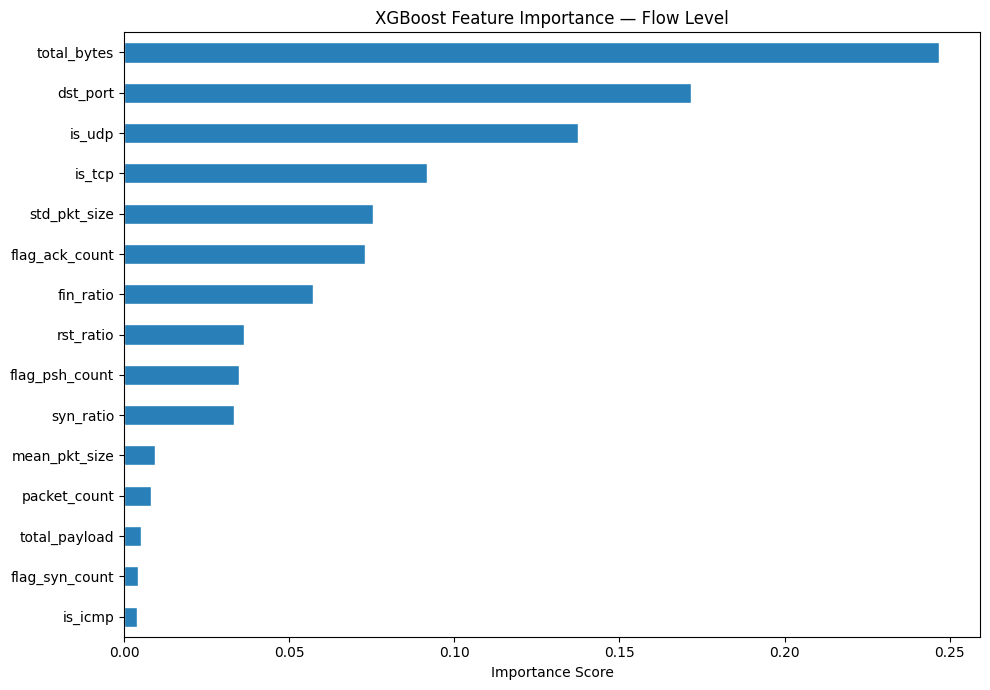


✅ Flow-level models saved to /kaggle/working/models
   Features: 26
   Classes : ['db_probe', 'ftp_probe', 'icmp_scan', 'iot_probe', 'port_scan', 'smb_exploit', 'snmp_probe', 'ssh_bruteforce', 'telnet_probe', 'vnc_bruteforce', 'web_scan']


In [10]:
# ─────────────────────────────────────────────
# CELL 9 — Flow-level labeling + train models
# ─────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import joblib, json

# ── Step 1: Label flows ───────────────────────
# Now we label the ENTIRE flow, not individual packets
# Much more accurate — we see the full connection behavior

def label_flow(row):
    port     = int(row['dst_port'])
    is_icmp  = int(row['is_icmp'])
    syn_scan = int(row['is_syn_scan'])
    pkts     = int(row['packet_count'])
    syn_r    = float(row['syn_ratio'])
    rst_r    = float(row['rst_ratio'])
    duration = float(row['flow_duration_sec'])

    # ICMP — always a scan/probe
    if is_icmp:
        return 'icmp_scan'

    # SYN scan — SYN sent, no ACK back = port scanner
    if syn_scan and pkts <= 2:
        return 'port_scan'

    # SSH
    if port == 22:
        # short duration + many SYNs = bruteforce
        if duration < 10 and syn_r > 0.3:
            return 'ssh_bruteforce'
        # longer session = successful login or deeper probe
        return 'ssh_bruteforce'

    # VNC
    if port == 5900:
        return 'vnc_bruteforce'

    # Telnet
    if port == 23:
        return 'telnet_probe'

    # Web
    if port in [80, 81, 8080, 8081, 8888, 443, 8443]:
        return 'web_scan'

    # Database
    if port in [1433, 3306, 27017, 5432, 6379, 9200]:
        return 'db_probe'

    # FTP
    if port == 21:
        return 'ftp_probe'

    # SNMP
    if port in [161, 162]:
        return 'snmp_probe'

    # IoT/MQTT
    if port in [1883, 8883]:
        return 'iot_probe'

    # RPC/Windows
    if port in [135, 139, 445]:
        return 'smb_exploit'

    # High port + SYN scan pattern = general scanner
    if syn_scan:
        return 'port_scan'

    # RST-heavy flows = connection refused probes
    if rst_r > 0.5 and pkts <= 4:
        return 'port_scan'

    return 'unknown'

print("Labeling flows...")
cic_flows['attack_label'] = cic_flows.apply(label_flow, axis=1)

print("\nFlow label distribution:")
label_counts = cic_flows['attack_label'].value_counts()
print(label_counts)
print(f"\nUnknown: {label_counts.get('unknown', 0):,} "
      f"({label_counts.get('unknown', 0)/len(cic_flows)*100:.1f}%)")

# ── Step 2: Feature matrix ────────────────────
FLOW_FEATURE_COLS = [
    'dst_port', 'src_port',
    'hour', 'day_of_week',
    'dst_port_bucket', 'src_port_bucket',
    'packet_count', 'total_bytes',
    'mean_pkt_size', 'std_pkt_size',
    'total_payload', 'mean_ttl',
    'flag_syn_count', 'flag_ack_count',
    'flag_rst_count', 'flag_fin_count',
    'flag_psh_count',
    'is_tcp', 'is_udp', 'is_icmp',
    'flow_duration_sec', 'bytes_per_packet',
    'syn_ratio', 'rst_ratio', 'fin_ratio',
    'is_syn_scan',
    'dst_port_bucket', 'src_port_bucket',
]

# remove duplicates in feature cols
FLOW_FEATURE_COLS = list(dict.fromkeys(FLOW_FEATURE_COLS))

labeled = cic_flows[cic_flows['attack_label'] != 'unknown'].copy()
print(f"\nLabeled flows: {len(labeled):,}")
print(f"Unlabeled (unknown): {(cic_flows['attack_label'] == 'unknown').sum():,}")

X = labeled[FLOW_FEATURE_COLS].fillna(0).astype(float)

le_flow = LabelEncoder()
y       = le_flow.fit_transform(labeled['attack_label'])

print(f"\nClasses ({len(le_flow.classes_)}): {list(le_flow.classes_)}")
print(f"X shape: {X.shape}")

# ── Step 3: Train/test split ──────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_np = X_train.values
X_test_np  = X_test.values

print(f"\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}")

# ── Step 4: Train XGBoost ─────────────────────
print("\nTraining XGBoost on flows...")
xgb_flow = XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    eval_metric='mlogloss',
)
xgb_flow.fit(X_train_np, y_train)
print("✅ XGBoost trained")

# ── Step 5: Train Random Forest ───────────────
print("Training Random Forest on flows...")
rf_flow = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1,
)
rf_flow.fit(X_train_np, y_train)
print("✅ Random Forest trained")

# ── Step 6: Evaluate ensemble ─────────────────
xgb_probs = xgb_flow.predict_proba(X_test_np)
rf_probs  = rf_flow.predict_proba(X_test_np)
ensemble  = (xgb_probs + rf_probs) / 2
y_pred    = np.argmax(ensemble, axis=1)

unique     = np.unique(np.concatenate([y_test, y_pred]))
class_names= le_flow.inverse_transform(unique)

print("\n=== FLOW-LEVEL ENSEMBLE REPORT ===")
print(classification_report(
    y_test, y_pred,
    labels=unique,
    target_names=class_names,
    zero_division=0
))
print(f"Overall accuracy: {(y_pred == y_test).mean()*100:.2f}%")

# ── Step 7: Feature importance ────────────────
import matplotlib.pyplot as plt

importance = pd.Series(
    xgb_flow.feature_importances_,
    index=FLOW_FEATURE_COLS
).sort_values(ascending=True).tail(15)

importance.plot(kind='barh', figsize=(10, 7),
                color='#2980B9', edgecolor='white')
plt.title('XGBoost Feature Importance — Flow Level')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(f'{BASE}/xgb_flow_importance.png', dpi=150)
plt.show()

# ── Step 8: Save ──────────────────────────────
joblib.dump(xgb_flow,  f'{MODELS}/xgboost_classifier.pkl')
joblib.dump(rf_flow,   f'{MODELS}/random_forest.pkl')
joblib.dump(le_flow,   f'{MODELS}/label_encoder.pkl')
with open(f'{MODELS}/feature_cols.json', 'w') as f:
    json.dump(FLOW_FEATURE_COLS, f)
with open(f'{MODELS}/flow_feature_cols.json', 'w') as f:
    json.dump(FLOW_FEATURE_COLS, f)

print(f"\n✅ Flow-level models saved to {MODELS}")
print(f"   Features: {len(FLOW_FEATURE_COLS)}")
print(f"   Classes : {list(le_flow.classes_)}")

In [11]:
# ─────────────────────────────────────────────
# CELL 9 — Summary + list saved models
# ─────────────────────────────────────────────
print("=" * 50)
print("HONEYCLOUD ML PIPELINE — COMPLETE")
print("=" * 50)

print("\nModels saved:")
for f in os.listdir(MODELS):
    size = os.path.getsize(f'{MODELS}/{f}') / 1024 / 1024
    print(f"  {f:<40} {size:.1f} MB")

print(f"""
Training data summary:
  Dionaea baseline  : 27,528 rows
  CIC full dataset  : 25M+ rows (31 days)
  
Models:
  Isolation Forest  — anomaly detection
  XGBoost + RF      — attack classification
  Label Encoder     — class name mapping
  Feature cols      — inference column order
  Hornet40 baseline — volumetric thresholds

Next: Download models → replace honeycloud/models/
      → rebuild PyPI package → honeycloud score
      uses real CIC-trained models
""")
print("=" * 50)
print("✅ Done.")
print("=" * 50)

HONEYCLOUD ML PIPELINE — COMPLETE

Models saved:
  random_forest.pkl                        26.1 MB
  label_encoder.pkl                        0.0 MB
  flow_feature_cols.json                   0.0 MB
  hornet40_baseline.json                   0.0 MB
  isolation_forest.pkl                     1.1 MB
  feature_cols_cic.json                    0.0 MB
  xgboost_classifier.pkl                   3.3 MB
  feature_cols.json                        0.0 MB

Training data summary:
  Dionaea baseline  : 27,528 rows
  CIC full dataset  : 25M+ rows (31 days)
  
Models:
  Isolation Forest  — anomaly detection
  XGBoost + RF      — attack classification
  Label Encoder     — class name mapping
  Feature cols      — inference column order
  Hornet40 baseline — volumetric thresholds

Next: Download models → replace honeycloud/models/
      → rebuild PyPI package → honeycloud score
      uses real CIC-trained models

✅ Done.


In [12]:
# ─────────────────────────────────────────────
# CELL 10 — Retrain Isolation Forest on flows
# ─────────────────────────────────────────────
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

# use the same flow feature matrix from Cell 9
X_flows = labeled[FLOW_FEATURE_COLS].fillna(0).astype(float)

print(f"Training Isolation Forest on {len(X_flows):,} flows...")
print(f"Features: {len(FLOW_FEATURE_COLS)} — {FLOW_FEATURE_COLS}\n")

flow_iso = Pipeline([
    ('scaler',     StandardScaler()),
    ('iso_forest', IsolationForest(
        n_estimators=100,
        contamination=0.05,
        random_state=42,
        n_jobs=-1,
    ))
])
flow_iso.fit(X_flows)

raw    = flow_iso.decision_function(X_flows)
scores = 1 - (raw - raw.min()) / (raw.max() - raw.min())
anomalies = (flow_iso.predict(X_flows) == -1).sum()

print(f"✅ Trained on {len(X_flows):,} flows")
print(f"   Features   : {len(FLOW_FEATURE_COLS)}")
print(f"   Anomalies  : {anomalies:,} ({anomalies/len(X_flows)*100:.1f}%)")
print(f"   Score range: {scores.min():.3f} — {scores.max():.3f}")

# save — overwrites the old one
joblib.dump(flow_iso, f'{MODELS}/isolation_forest.pkl')
print(f"\n✅ Saved: {MODELS}/isolation_forest.pkl")
print(f"   Size: {os.path.getsize(f'{MODELS}/isolation_forest.pkl')/1024/1024:.1f} MB")

Training Isolation Forest on 32,125 flows...
Features: 26 — ['dst_port', 'src_port', 'hour', 'day_of_week', 'dst_port_bucket', 'src_port_bucket', 'packet_count', 'total_bytes', 'mean_pkt_size', 'std_pkt_size', 'total_payload', 'mean_ttl', 'flag_syn_count', 'flag_ack_count', 'flag_rst_count', 'flag_fin_count', 'flag_psh_count', 'is_tcp', 'is_udp', 'is_icmp', 'flow_duration_sec', 'bytes_per_packet', 'syn_ratio', 'rst_ratio', 'fin_ratio', 'is_syn_scan']

✅ Trained on 32,125 flows
   Features   : 26
   Anomalies  : 1,607 (5.0%)
   Score range: 0.000 — 1.000

✅ Saved: /kaggle/working/models/isolation_forest.pkl
   Size: 0.8 MB


In [16]:
# ─────────────────────────────────────────────
# CELL 11 — Build Bi-LSTM Sequence Dataset
# ─────────────────────────────────────────────
import numpy as np
from sklearn.preprocessing import LabelEncoder

SEQ_LEN = 5

print(f"Total labeled flows : {len(labeled):,}")
print(f"Unique src_ips      : {labeled['src_ip'].nunique():,}")
print(f"Sequence length N   : {SEQ_LEN}")
print(f"Features per step   : {len(FLOW_FEATURE_COLS)}")

# Sort by IP then time
seq_df = labeled.sort_values(['src_ip', 'start_time']).reset_index(drop=True)

# Fit a fresh encoder on ALL classes present in this dataframe
lstm_le = LabelEncoder()
seq_df['label_int'] = lstm_le.fit_transform(seq_df['attack_label'])
NUM_CLASSES = len(lstm_le.classes_)

print(f"\nClasses found ({NUM_CLASSES}):")
for i, cls in enumerate(lstm_le.classes_):
    print(f"  {i:>2}  {cls}")

# Save it — inference will need it
import joblib
joblib.dump(lstm_le, f'{MODELS}/lstm_label_encoder.pkl')
print(f"\n✅ Saved: {MODELS}/lstm_label_encoder.pkl")

# Build sequences using sliding window per src_ip
X_seq = []
y_seq = []
skipped = 0

for ip, grp in seq_df.groupby('src_ip'):
    grp = grp.reset_index(drop=True)
    if len(grp) < SEQ_LEN + 1:
        skipped += 1
        continue
    feats  = grp[FLOW_FEATURE_COLS].fillna(0).astype(float).values
    labels = grp['label_int'].values
    for i in range(len(grp) - SEQ_LEN):
        X_seq.append(feats[i : i + SEQ_LEN])
        y_seq.append(labels[i + SEQ_LEN])

X_seq = np.array(X_seq, dtype=np.float32)
y_seq = np.array(y_seq, dtype=np.int32)

print(f"\n✅ Sequence dataset built")
print(f"   X shape     : {X_seq.shape}")
print(f"   y shape     : {y_seq.shape}")
print(f"   IPs skipped : {skipped} (< {SEQ_LEN+1} flows)")
print(f"\nClass distribution in y:")
for idx, cls in enumerate(lstm_le.classes_):
    n = (y_seq == idx).sum()
    print(f"  {cls:<20} {n:>5}  ({n/len(y_seq)*100:.1f}%)")

Total labeled flows : 32,125
Unique src_ips      : 15,030
Sequence length N   : 5
Features per step   : 26

Classes found (11):
   0  db_probe
   1  ftp_probe
   2  icmp_scan
   3  iot_probe
   4  port_scan
   5  smb_exploit
   6  snmp_probe
   7  ssh_bruteforce
   8  telnet_probe
   9  vnc_bruteforce
  10  web_scan

✅ Saved: /kaggle/working/models/lstm_label_encoder.pkl

✅ Sequence dataset built
   X shape     : (9386, 5, 26)
   y shape     : (9386,)
   IPs skipped : 14240 (< 6 flows)

Class distribution in y:
  db_probe               920  (9.8%)
  ftp_probe              156  (1.7%)
  icmp_scan                2  (0.0%)
  iot_probe               79  (0.8%)
  port_scan             2491  (26.5%)
  smb_exploit             19  (0.2%)
  snmp_probe              65  (0.7%)
  ssh_bruteforce         884  (9.4%)
  telnet_probe           495  (5.3%)
  vnc_bruteforce        3123  (33.3%)
  web_scan              1152  (12.3%)


In [17]:
# ─────────────────────────────────────────────
# CELL 12 — Normalise + Split
# ─────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Flatten to 2D for scaler, then reshape back
n_samples, n_steps, n_feats = X_seq.shape
X_flat = X_seq.reshape(-1, n_feats)

seq_scaler = StandardScaler()
X_flat_scaled = seq_scaler.fit_transform(X_flat)

X_scaled = X_flat_scaled.reshape(n_samples, n_steps, n_feats).astype(np.float32)

# Stratified split — keep class balance in train/val
X_tr, X_val, y_tr, y_val = train_test_split(
    X_scaled, y_seq,
    test_size=0.15,
    random_state=42,
    stratify=y_seq
)

print(f"Train : {X_tr.shape}  labels: {y_tr.shape}")
print(f"Val   : {X_val.shape}  labels: {y_val.shape}")

# Save scaler alongside model later
import joblib
joblib.dump(seq_scaler, f'{MODELS}/lstm_scaler.pkl')
print(f"\n✅ Scaler saved → {MODELS}/lstm_scaler.pkl")

Train : (7978, 5, 26)  labels: (7978,)
Val   : (1408, 5, 26)  labels: (1408,)

✅ Scaler saved → /kaggle/working/models/lstm_scaler.pkl


In [18]:
# ─────────────────────────────────────────────
# CELL 13 — Define + Train Bi-LSTM
# ─────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras import layers, callbacks
import os

tf.random.set_seed(42)
print(f"TF version : {tf.__version__}")
print(f"Input shape: ({SEQ_LEN}, {n_feats})  →  {NUM_CLASSES} classes\n")

# ── Model ────────────────────────────────────
inp = layers.Input(shape=(SEQ_LEN, n_feats), name="flow_seq")

x = layers.Bidirectional(
    layers.LSTM(128, return_sequences=True, dropout=0.2),
    name="bilstm_1"
)(inp)

x = layers.Bidirectional(
    layers.LSTM(64, return_sequences=False, dropout=0.2),
    name="bilstm_2"
)(x)

x = layers.Dense(64, activation="relu", name="dense_1")(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation="softmax", name="predictions")(x)

model = tf.keras.Model(inp, out, name="honeycloud_bilstm")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ── Callbacks ────────────────────────────────
ckpt_path = f"{MODELS}/bilstm_best.keras"
cbs = [
    callbacks.EarlyStopping(
        monitor="val_loss", patience=5,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ModelCheckpoint(
        ckpt_path, monitor="val_accuracy",
        save_best_only=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=3, min_lr=1e-5, verbose=1
    )
]

# ── Class weights (handle imbalance) ─────────
from sklearn.utils.class_weight import compute_class_weight
cw_vals = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=y_tr
)
class_weights = dict(enumerate(cw_vals))

# ── Train ─────────────────────────────────────
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=256,
    class_weight=class_weights,
    callbacks=cbs,
    verbose=1
)

print(f"\n✅ Training complete")
print(f"   Best val_accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"   Best val_loss     : {min(history.history['val_loss']):.4f}")

2026-03-16 07:26:16.668634: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773645976.985060      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773645977.083195      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773645977.813845      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773645977.813897      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773645977.813901      55 computation_placer.cc:177] computation placer alr

TF version : 2.19.0
Input shape: (5, 26)  →  11 classes



2026-03-16 07:26:47.684041: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "honeycloud_bilstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flow_seq (InputLayer)           │ (None, 5, 26)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 5, 256)         │       158,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,043 (1.27 MB)

 Trainable params: 332,043 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.2694 - loss: 2.2653
Epoch 1: val_accuracy improved from -inf to 0.61719, saving model to /kaggle/working/models/bilstm_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - accuracy: 0.2767 - loss: 2.2609 - val_accuracy: 0.6172 - val_loss: 1.8185 - learning_rate: 0.0010
Epoch 2/40
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5898 - loss: 1.8401
Epoch 2: val_accuracy improved from 0.61719 to 0.67188, saving model to /kaggle/working/models/bilstm_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.5920 - loss: 1.8392 - val_accuracy: 0.6719 - val_loss: 1.2781 - learning_rate: 0.0010
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6774 - loss: 1.5777
Epoch 3: val_accuracy improved from 0.67188 to 0.68537, saving model to /kaggle/working/models/bilstm_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.6773 - loss: 1.5780 - val_accuracy: 0.6854 - val_loss: 1.0982 - learning_ra

In [19]:
# ─────────────────────────────────────────────
# CELL 14 — Evaluate + Save All LSTM Artifacts
# ─────────────────────────────────────────────
from sklearn.metrics import classification_report
import json

y_pred_probs = model.predict(X_val, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

print("Classification Report:\n")
print(classification_report(
    y_val, y_pred,
    target_names=lstm_le.classes_,   # ← lstm_le not le
    digits=3
))

report = classification_report(
    y_val, y_pred,
    target_names=lstm_le.classes_,   # ← lstm_le not le
    output_dict=True
)
print("\nPer-class F1:")
for cls in lstm_le.classes_:
    f1 = report[cls]['f1-score']
    bar = "█" * int(f1 * 20)
    print(f"  {cls:<20} {bar:<20} {f1:.3f}")

# Save Keras model
model.save(f"{MODELS}/bilstm_model.keras")
print(f"\n✅ Saved: {MODELS}/bilstm_model.keras")

# Save metadata
meta = {
    "seq_len"      : SEQ_LEN,
    "n_features"   : int(n_feats),
    "num_classes"  : int(NUM_CLASSES),
    "classes"      : list(lstm_le.classes_),   # ← lstm_le not le
    "feature_cols" : FLOW_FEATURE_COLS,
    "val_accuracy" : float(max(history.history['val_accuracy'])),
    "val_loss"     : float(min(history.history['val_loss'])),
}
with open(f"{MODELS}/bilstm_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print(f"✅ Saved: {MODELS}/bilstm_meta.json")

print(f"\nAll LSTM artifacts in {MODELS}:")
for fname in sorted(os.listdir(MODELS)):
    if 'lstm' in fname or 'bilstm' in fname:
        size = os.path.getsize(f"{MODELS}/{fname}") / 1024 / 1024
        print(f"  {fname:<40} {size:.2f} MB")

Classification Report:

                precision    recall  f1-score   support

      db_probe      0.520     0.384     0.442       138
     ftp_probe      0.079     0.130     0.098        23
     icmp_scan      0.000     0.000     0.000         0
     iot_probe      0.039     0.167     0.063        12
     port_scan      0.858     0.778     0.816       374
   smb_exploit      0.008     0.333     0.015         3
    snmp_probe      0.059     0.300     0.098        10
ssh_bruteforce      0.943     0.744     0.832       133
  telnet_probe      0.600     0.770     0.675        74
vnc_bruteforce      0.987     0.957     0.972       468
      web_scan      0.733     0.127     0.217       173

      accuracy                          0.695      1408
     macro avg      0.439     0.427     0.384      1408
  weighted avg      0.820     0.695     0.727      1408


Per-class F1:
  db_probe             ████████             0.442
  ftp_probe            █                    0.098
  icmp_scan       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

In [20]:
# ─────────────────────────────────────────────
# CELL 15 — Inference Smoke Test
# ─────────────────────────────────────────────
import tensorflow as tf, json, joblib, numpy as np

# Reload everything cold (simulates score.py)
_lstm_model  = tf.keras.models.load_model(f"{MODELS}/bilstm_model.keras")
_lstm_scaler = joblib.load(f"{MODELS}/lstm_scaler.pkl")
_lstm_le     = joblib.load(f"{MODELS}/lstm_label_encoder.pkl")  # ← lstm_le
with open(f"{MODELS}/bilstm_meta.json") as f:
    _lstm_meta = json.load(f)

SEQ   = _lstm_meta["seq_len"]
FEATS = _lstm_meta["feature_cols"]
CLS   = _lstm_meta["classes"]

def predict_next_attack(flow_sequence: list) -> dict:
    """
    flow_sequence : list of SEQ dicts, keys = FLOW_FEATURE_COLS
    Returns       : {class_name: probability} sorted descending
    """
    assert len(flow_sequence) == SEQ, f"Need exactly {SEQ} flows"
    X = np.array([[f.get(col, 0.0) for col in FEATS]
                  for f in flow_sequence], dtype=np.float32)
    X_s = _lstm_scaler.transform(X).reshape(1, SEQ, len(FEATS))
    probs = _lstm_model.predict(X_s, verbose=0)[0]
    return dict(sorted(zip(CLS, probs.tolist()), key=lambda x: -x[1]))

# ── Fake SSH brute-force sequence ─────────────
fake_ssh = []
for i in range(SEQ):
    fake_ssh.append({
        "dst_port": 22.0,        "src_port": 50000.0 + i,
        "hour": 3.0,             "day_of_week": 1.0,
        "dst_port_bucket": 0.0,  "src_port_bucket": 1.0,
        "packet_count": 4.0,     "total_bytes": 400.0,
        "mean_pkt_size": 100.0,  "std_pkt_size": 10.0,
        "total_payload": 240.0,  "mean_ttl": 64.0,
        "flag_syn_count": 3.0,   "flag_ack_count": 1.0,
        "flag_rst_count": 0.0,   "flag_fin_count": 0.0,
        "flag_psh_count": 0.0,   "is_tcp": 1.0,
        "is_udp": 0.0,           "is_icmp": 0.0,
        "flow_duration_sec": 0.5,"bytes_per_packet": 100.0,
        "syn_ratio": 0.75,       "rst_ratio": 0.0,
        "fin_ratio": 0.0,        "is_syn_scan": 0.0,
    })

# ── Fake port scan sequence ───────────────────
fake_portscan = []
for i in range(SEQ):
    fake_portscan.append({
        "dst_port": float(1000 + i * 100), "src_port": 45000.0,
        "hour": 14.0,            "day_of_week": 3.0,
        "dst_port_bucket": 0.0,  "src_port_bucket": 1.0,
        "packet_count": 1.0,     "total_bytes": 60.0,
        "mean_pkt_size": 60.0,   "std_pkt_size": 0.0,
        "total_payload": 0.0,    "mean_ttl": 128.0,
        "flag_syn_count": 1.0,   "flag_ack_count": 0.0,
        "flag_rst_count": 0.0,   "flag_fin_count": 0.0,
        "flag_psh_count": 0.0,   "is_tcp": 1.0,
        "is_udp": 0.0,           "is_icmp": 0.0,
        "flow_duration_sec": 0.01,"bytes_per_packet": 60.0,
        "syn_ratio": 1.0,        "rst_ratio": 0.0,
        "fin_ratio": 0.0,        "is_syn_scan": 1.0,
    })

for label, seq in [("SSH brute-force", fake_ssh),
                   ("Port scan",       fake_portscan)]:
    result = predict_next_attack(seq)
    top    = list(result.keys())[0]
    print(f"\n── {label} context ──")
    for cls, prob in result.items():
        bar = "█" * int(prob * 40)
        print(f"  {cls:<20} {bar:<40} {prob:.3f}")
    print(f"  → Next move: {top}  ({result[top]:.1%})")

print("\n✅ Bi-LSTM inference working end-to-end.")


── SSH brute-force context ──
  db_probe             █████████████                            0.338
  smb_exploit          ████████                                 0.216
  telnet_probe         ██████                                   0.161
  web_scan             ████                                     0.109
  ftp_probe            █                                        0.046
  ssh_bruteforce       █                                        0.043
  iot_probe            █                                        0.039
  snmp_probe                                                    0.024
  port_scan                                                     0.015
  icmp_scan                                                     0.007
  vnc_bruteforce                                                0.002
  → Next move: db_probe  (33.8%)

── Port scan context ──
  smb_exploit          █████████████████                        0.449
  snmp_probe           ██████                                   0.151
 

In [22]:
# ─────────────────────────────────────────────
# CELL 16 — Export to TFLite (fixed for BiLSTM)
# ─────────────────────────────────────────────
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Required for Bidirectional LSTM ops
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

with open(f"{MODELS}/bilstm_model.tflite", "wb") as f:
    f.write(tflite_model)

size = os.path.getsize(f"{MODELS}/bilstm_model.tflite") / 1024 / 1024
print(f"✅ Saved: bilstm_model.tflite  ({size:.2f} MB)")

INFO:tensorflow:Assets written to: /tmp/tmpqz0zhqe7/assets


INFO:tensorflow:Assets written to: /tmp/tmpqz0zhqe7/assets


Saved artifact at '/tmp/tmpqz0zhqe7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5, 26), dtype=tf.float32, name='flow_seq')
Output Type:
  TensorSpec(shape=(None, 11), dtype=tf.float32, name=None)
Captures:
  136976031312272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136976031314000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136976031314576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136976031316688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136976031311696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136976031313424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136976031312656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136976031315920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136976031315536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136976031317072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136976031315344: Tensor

W0000 00:00:1773646875.306362      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1773646875.306408      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


In [25]:
# ─────────────────────────────────────────────
# CELL 17 — Export to ONNX
# ─────────────────────────────────────────────
import subprocess
subprocess.run(["pip", "install", "tf2onnx", "-q"], check=True)

import tf2onnx
import tensorflow as tf

spec = (tf.TensorSpec((None, 5, 26), tf.float32, name="flow_seq"),)
output_path = f"{MODELS}/bilstm_model.onnx"

model_proto, _ = tf2onnx.convert.from_keras(
    model,
    input_signature=spec,
    opset=13,
    output_path=output_path
)

size = os.path.getsize(output_path) / 1024 / 1024
print(f"✅ Saved: bilstm_model.onnx  ({size:.2f} MB)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 13.8 MB/s eta 0:00:00


I0000 00:00:1773647173.269527      55 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00:1773647173.269844      55 single_machine.cc:374] Starting new session
I0000 00:00:1773647173.376529      55 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00:1773647173.376737      55 single_machine.cc:374] Starting new session
I0000 00:00:1773647173.508180      55 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00:1773647173.508366      55 single_machine.cc:374] Starting new session


✅ Saved: bilstm_model.onnx  (1.31 MB)
